## Volume of Aluminum Probe

In [1]:
import numpy as np

diameter = 17.52 #mm
radius = diameter / 2 #mm
length = 52.2 #mm

cylinder_vol_mm3 = radius**2 * np.pi * length #mm^3
cylinder_vol_cm3 = cylinder_vol_mm3 / 1000 #cm^3

cone_height = 8.02 #mm
cone_volume_mm3 = (1/3) * np.pi * radius**2 * cone_height
cone_volume_cm3 = cone_volume_mm3 / 1000 #cm^3


four_fin_mass = 1.27 #g
PLA_density = 1.43 #g/cm
four_fin_vol_cm3 = four_fin_mass / PLA_density

probe_vol_cm3 = cylinder_vol_cm3 + cone_volume_cm3 + four_fin_vol_cm3
print(f"Probe volume: {probe_vol_cm3:.2f} cm^3")

Probe volume: 14.12 cm^3


## Weighing Probe
Note that the wires/tail of probe are mostly off the scale. This is intentional, with the goal of measureing the weight of the probe without wires.

<img src="doc_images\how_to_mass_probe.jpeg" alt="Description" width="35%" height="35%">

In [2]:
probe_mass = 40.
d = probe_mass / probe_vol_cm3
print(d)

2.8334871398801647


In [3]:
1.575-.736

0.839

Density of Wet Sand

In [ ]:
rho_wet_sand = 1.964

In [2]:
import re
from pathlib import Path

import pandas as pd
import trim_data_file

source_csv = r"Data\frequencyVdepth4.csv"
trimmed_csv = Path(re.sub(r"(\.csv)$", r"_trimmed\1", source_csv))

trim_data_file.trim_csv_to_consistent_format(source_csv, trimmed_csv)
data = pd.read_csv(trimmed_csv)


## 16v might be the limit
Motor started smoking ~10 seconds into 17 volt test

Trying to identify Mystery metal

In [3]:
import numpy as np
mass = 957 #g
diameter = 1.94 #cm
length = 20.64 #cm
density = mass / (np.pi * (diameter/2)**2 * length)
print(f"Density: {density:.2f} g/cm^3")

Density: 15.69 g/cm^3


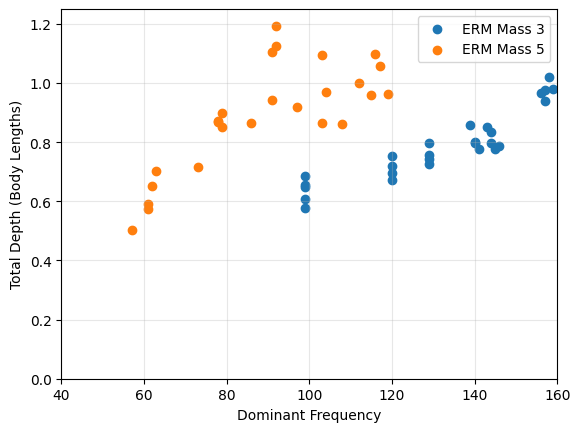

In [4]:
import numpy as np
import matplotlib.pyplot as plt
probe_length = 60.2

fig, ax = plt.subplots()
ax.grid(True, alpha=0.3)

for mass in [3, 5]:
    subset = data[data["ERM Mass"] == mass]
    x = subset["Peak Frequency"].astype(float)
    y = (subset["Total Depth (mm)"] / probe_length).astype(float)

    ax.scatter(
        x,
        y,
        marker="o",
        label=f"ERM Mass {mass}"
    )


ax.set_xlabel("Dominant Frequency")
ax.set_ylabel("Total Depth (Body Lengths)")
ax.set_ylim(0, 1.25)
ax.set_xlim(40, 160)
ax.legend(loc="best")

plt.show()

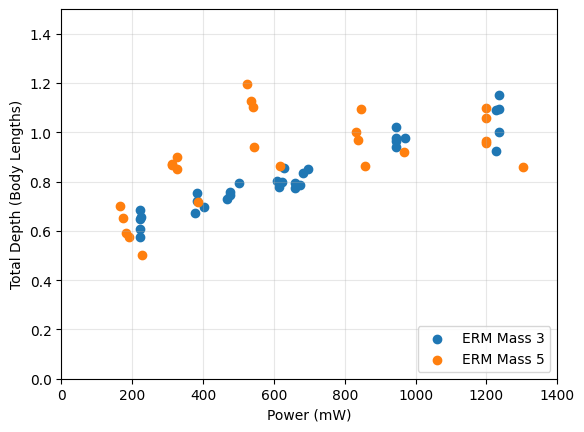

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

for mass in [3, 5]:
    subset = data[data["ERM Mass"] == mass]
    x = subset["Power (mW)"].astype(float)
    y = subset["Total Depth (mm)"].astype(float)/probe_length

    ax.scatter(
        x,
        y,
        marker="o",
        label=f"ERM Mass {mass}",
    )


ax.set_xlabel("Power (mW)")
ax.set_ylabel("Total Depth (Body Lengths)")
ax.legend(loc="lower right")
ax.set_ylim(0, 1.5)
ax.set_xlim(0,1400)
ax.grid(True, alpha=0.3)

plt.show()

## Plot kinetic power vs depth

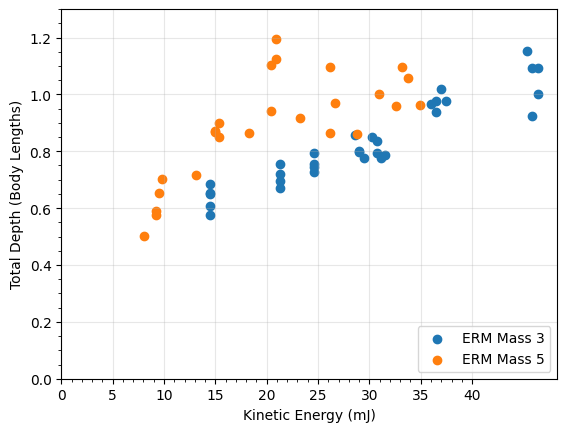

In [6]:
import numpy as np
import matplotlib.pyplot as plt

probe_length = 60.2

fig, ax = plt.subplots()
r = 0.005 # distance from center of probe to center of ERM mass
for mass in [3, 5]:
    subset = data[data["ERM Mass"] == mass]
    frequency_hz = subset["Peak Frequency"].astype(float)
    omega = 2 * np.pi * frequency_hz
    ke = 0.5 * mass * 0.001 * omega**2 * r**2 * 1000
    depth_body_lengths = subset["Total Depth (mm)"] / probe_length

    ax.scatter(
        ke,
        depth_body_lengths,
        marker="o",
        label=f"ERM Mass {mass}",
    )

ax.set_xlabel("Kinetic Energy (mJ)")
ax.set_ylabel("Total Depth (Body Lengths)")
ax.legend(loc="lower right")

ax.set_yticks(np.arange(0, 1.31, 0.2))
ax.set_yticks(np.arange(0, 1.31, 0.2/4), minor =True)
ax.set_xticks(np.arange(0, 41, 5))
ax.set_xticks(np.arange(0, 41, 5/5), minor=True)
ax.grid(True, alpha=0.3)

plt.show()

## Force = Power / Angular Velocity

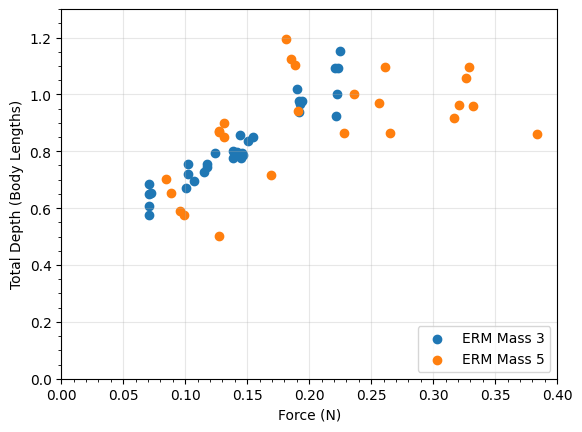

In [7]:
import numpy as np
import matplotlib.pyplot as plt

probe_length = 60.2

fig, ax = plt.subplots()
r = 0.005 # distance from center of probe to center of ERM mass
for mass in [3, 5]:
    subset = data[data["ERM Mass"] == mass]
    frequency_hz = subset["Peak Frequency"].astype(float)
    power = subset["Power (mW)"].astype(float)
    omega = 2 * np.pi * frequency_hz
    force = power * 0.001 / (omega * r)
    depth_body_lengths = subset["Total Depth (mm)"] / probe_length

    ax.scatter(
        force,
        depth_body_lengths,
        marker="o",
        label=f"ERM Mass {mass}",
    )
ax.set_xlabel("Force (N)")
ax.set_ylabel("Total Depth (Body Lengths)")
ax.legend(loc="lower right")
#ax.set_ylim(0, 1.3)
#ax.set_xlim(0.00, 0.4)
ax.set_yticks(np.arange(0, 1.31, 0.2))
ax.set_yticks(np.arange(0, 1.31, 0.2/4), minor =True)
ax.set_xticks(np.arange(0, 0.401, 0.05))
ax.set_xticks(np.arange(0, 0.401, 0.05/5), minor=True)

ax.grid(True, alpha=0.3)

plt.show()

## Power Draw vs Frequency

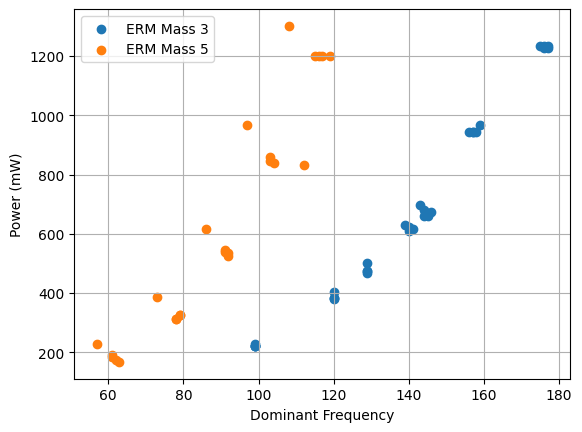

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

for mass in [3, 5]:
    subset = data[data["ERM Mass"] == mass]
    ax.scatter(
        subset["Peak Frequency"],
        subset["Power (mW)"],
        marker="o",
        label=f"ERM Mass {mass}",
    )

ax.set_xlabel("Dominant Frequency")
ax.set_ylabel("Power (mW)")
ax.legend(loc="best")
ax.grid(True)

plt.show()

## Frequncy Spectrum

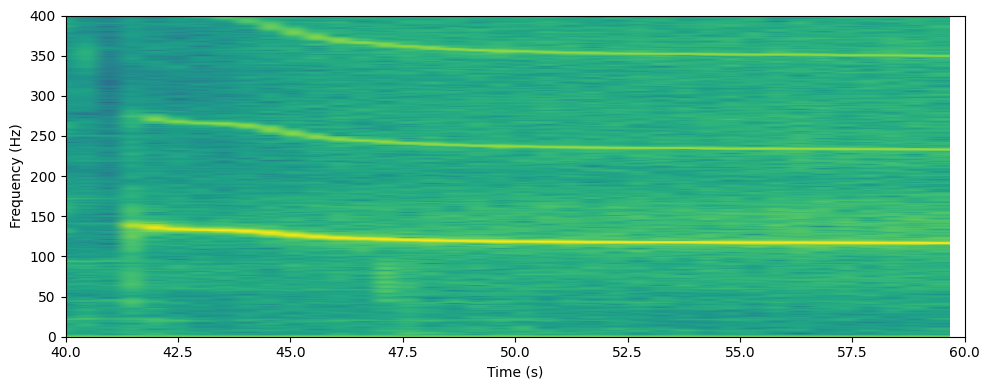

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

wav_path = os.path.join(os.getcwd(), "Data", "m5-740v-d.wav")
sample_rate, audio = wavfile.read(wav_path)

start_sec = 0
end_sec = 60
start_sample = int(start_sec * sample_rate)
end_sample = int(min(end_sec * sample_rate, len(audio)))
audio_slice = audio[start_sample:end_sample]

if audio_slice.ndim > 1:
    audio_slice = audio_slice.mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))

# Simple spectrogram using short-time Fourier transform
window = 4096
noverlap = window // 2

Pxx, freqs, bins, im = plt.specgram(
    audio_slice,
    Fs=sample_rate,
    NFFT=window,
    noverlap=noverlap,
    cmap="viridis",
)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_xlim(40, end_sec - start_sec)
ax.set_ylim(0, 400)
plt.tight_layout()
plt.show()